# Haiku Example 1: CODEX + H&E Patch Visualization

This notebook visualizes preprocessed CODEX and H&E patches from the demo dataset:
- **3 example patches** from different tissue regions with multi-channel biomarker views
- **Whole-region mosaic** reconstructed from all patches of a single region

Data is fetched from HuggingFace (`zhihuanglab/Haiku-demo-data`, gated-manual) on first run and cached locally. No local dataset paths required — just request access to the repo and set `HF_TOKEN`.

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import snapshot_download

# The notebook lives at <repo>/example_retrieval/ — repo root is one level up.
HAIKU_ROOT = Path.cwd().parent

# Pull demo data from HF (cached under ~/.cache/huggingface after first run).
DATA_REPO = 'zhihuanglab/Haiku-demo-data'  # gated-manual; request access + HF_TOKEN
DATASET_ROOT = Path(snapshot_download(
    repo_id=DATA_REPO,
    repo_type='dataset',
    token=os.environ.get('HF_TOKEN'),
))

EXAMPLE_DIR = DATASET_ROOT / 'example_slices'
# Use ada-28577 for whole-region mosaic (largest region, 262 patches)
MOSAIC_REGION = 'ada-28577'


def norm01(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)


print(f'HAIKU_ROOT  : {HAIKU_ROOT}')
print(f'DATASET_ROOT: {DATASET_ROOT}')
print(f'EXAMPLE_DIR : {EXAMPLE_DIR}')
print(f'Mosaic      : {MOSAIC_REGION}')

Fetching 2885 files:   0%|          | 0/2885 [00:00<?, ?it/s]

HAIKU_ROOT  : /home/yancui/Haiku
DATASET_ROOT: /home/yancui/.cache/huggingface/hub/datasets--zhihuanglab--Haiku-demo-data/snapshots/06a23ac67ed78c81d3e1ca3a4da94e044dae2539
EXAMPLE_DIR : /home/yancui/.cache/huggingface/hub/datasets--zhihuanglab--Haiku-demo-data/snapshots/06a23ac67ed78c81d3e1ca3a4da94e044dae2539/example_slices
Mosaic      : ada-28577


In [2]:
# Load the 3 example patches (one from each of 3 regions used in retrieval)
pkl_files = sorted(EXAMPLE_DIR.glob('*.pkl'))

examples = []
for pf in pkl_files:
    with open(pf, 'rb') as f:
        d = pickle.load(f)
    he = np.load(EXAMPLE_DIR / f'{pf.stem}.npy')
    region = pf.stem.split('_')[0] + '-' + pf.stem.split('_')[1].split('-')[0]
    # Extract region from filename: xxx-xxxxx_coords -> xxx-xxxxx
    region = '-'.join(pf.stem.split('_')[0:1]) if '-' in pf.stem.split('_')[0] else pf.stem.rsplit('_', 1)[0]
    examples.append({
        'name': pf.stem,
        'region': region,
        'codex': d['codex'],
        'markers': d['biomarker_name'],
        'he': he,
    })

print(f'Loaded {len(examples)} example patches:')
for e in examples:
    print(f'  {e["region"]} | {e["name"]} | {e["codex"].shape[0]} channels')


Loaded 3 example patches:
  abd-10769 | abd-10769_1646-1902-2970-3226 | 52 channels
  abs-74477 | abs-74477_2956-3212-2529-2785 | 53 channels
  ada-28577 | ada-28577_2908-3164-1903-2159 | 53 channels


### Single-Patch Detail: H&E + Biomarker Channels

Each patch shows the registered H&E image alongside individual biomarker channels
and an RGB composite overlay.


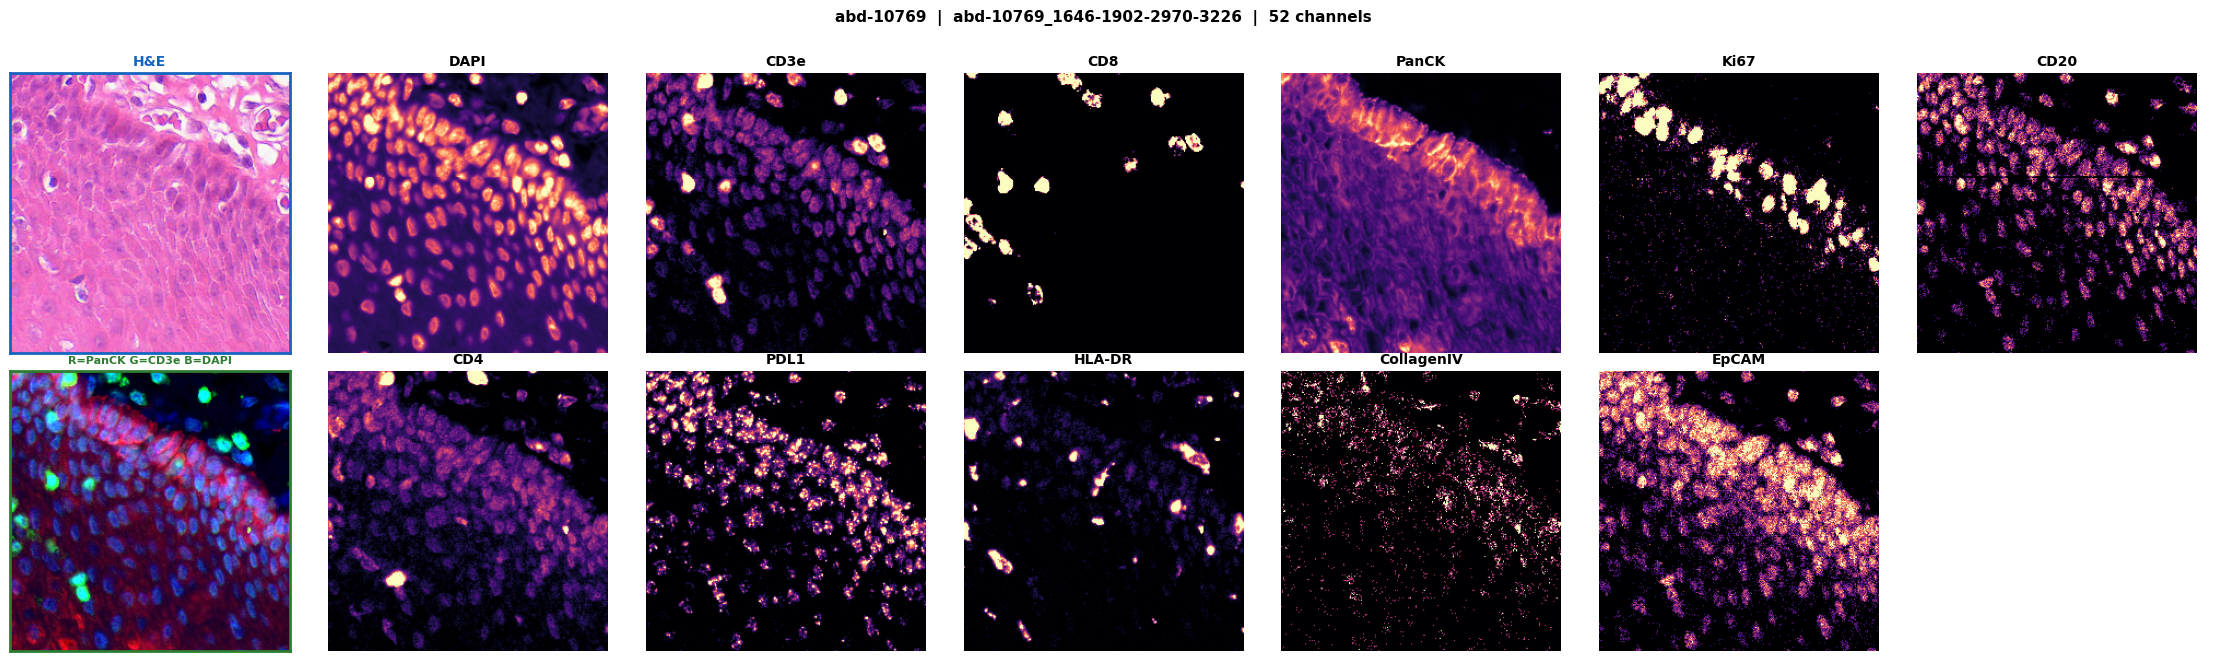

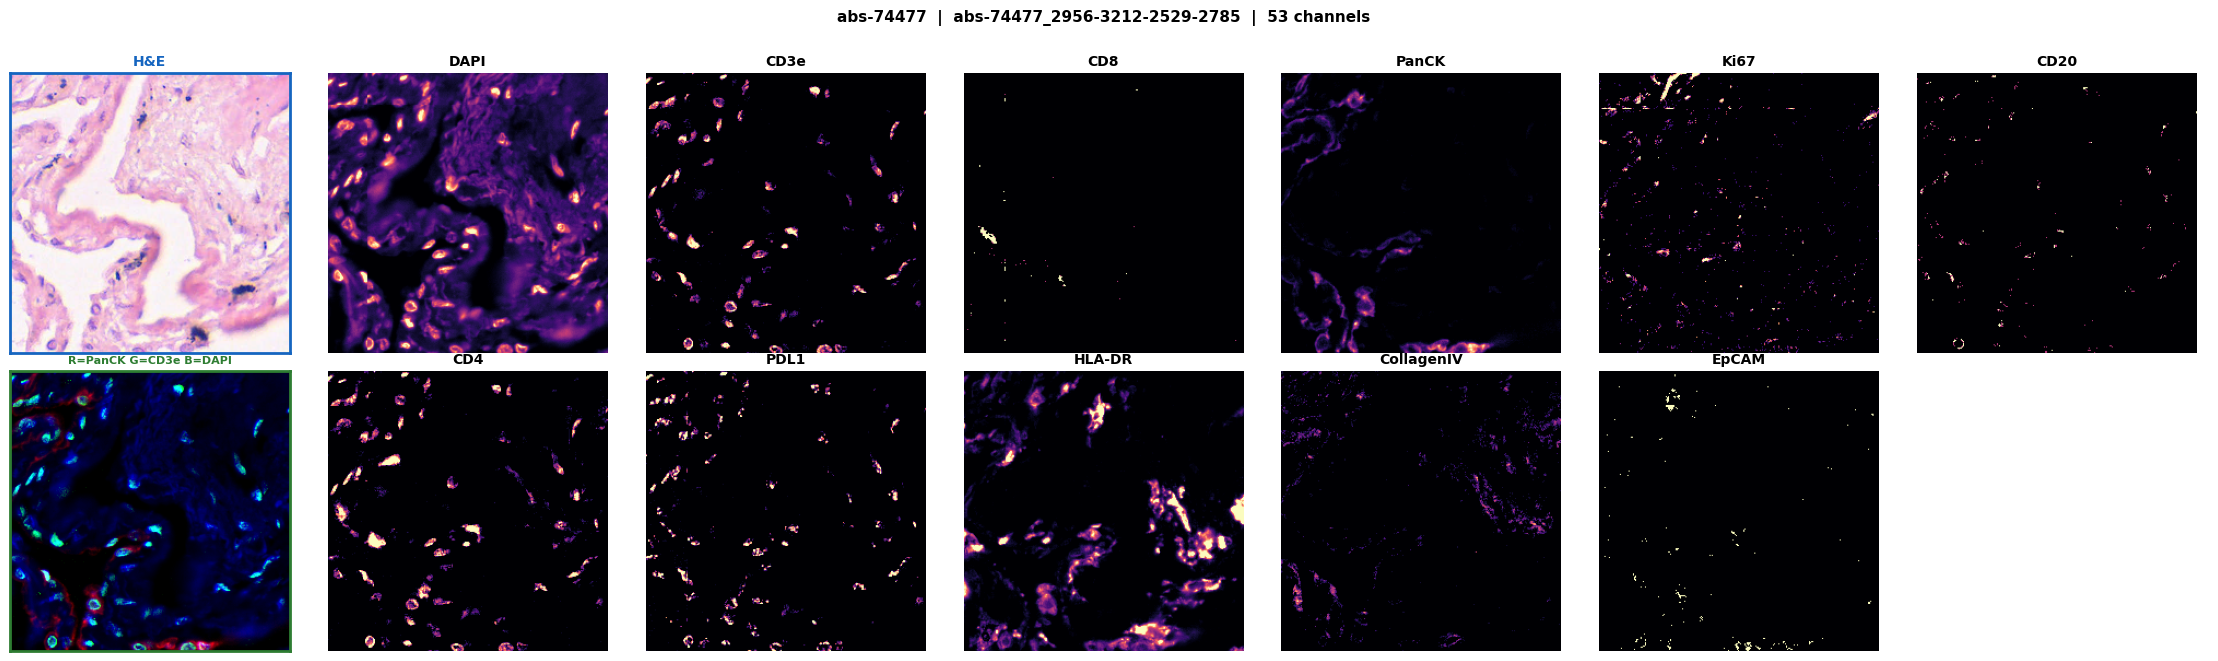

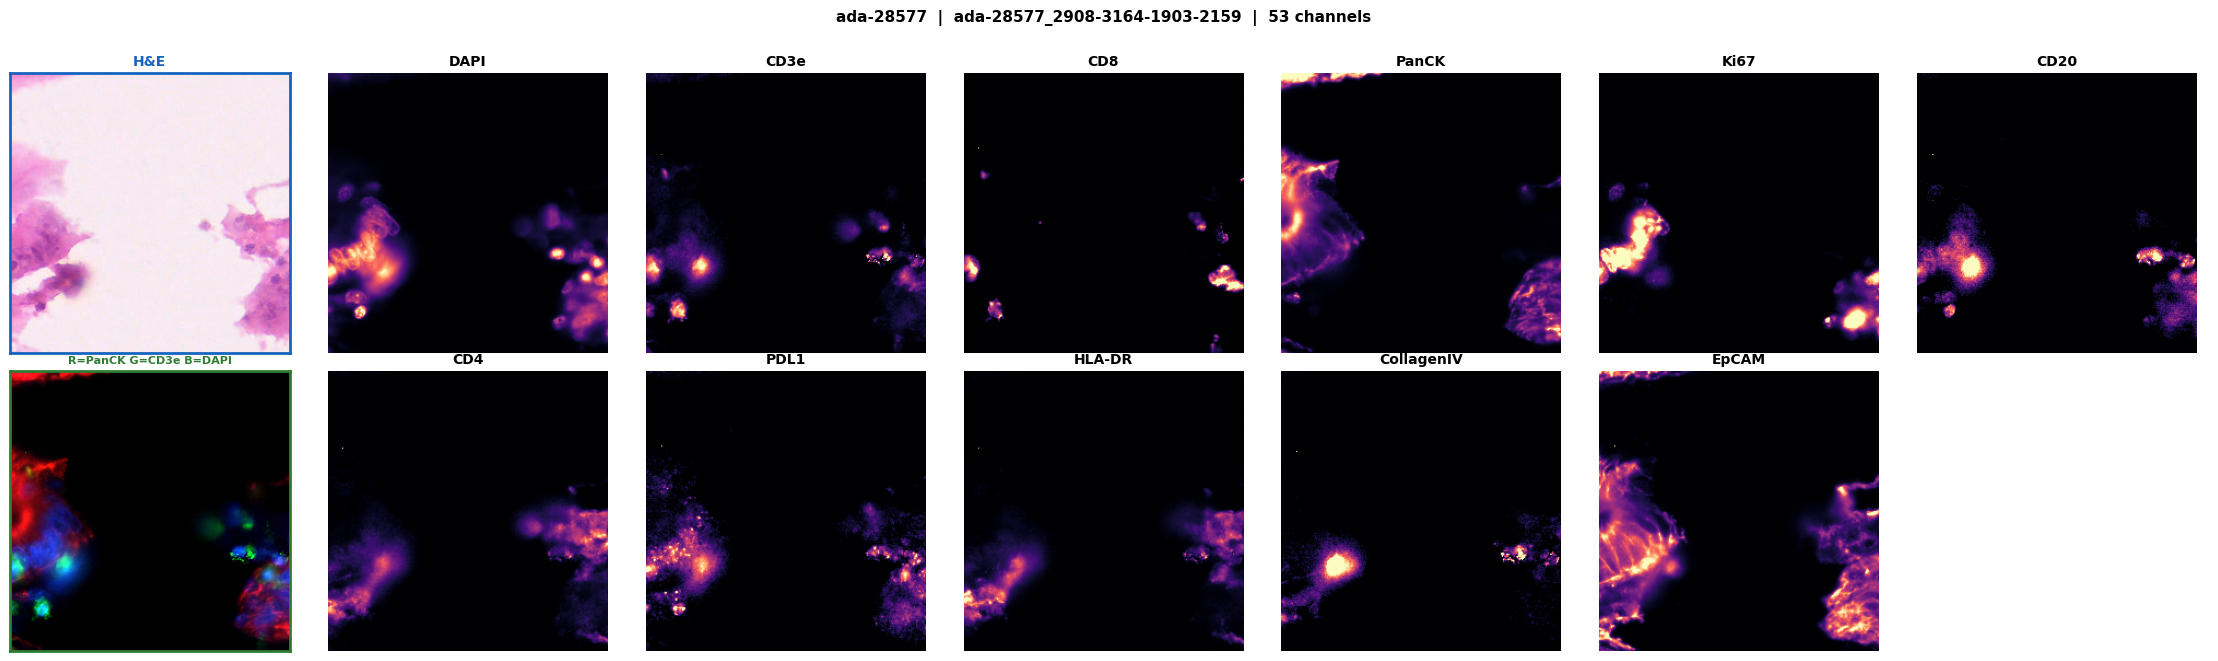

In [3]:
# Markers to display (common across panels)
row1_markers = ['DAPI', 'CD3e', 'CD8', 'PanCK', 'Ki67', 'CD20']
row2_markers = ['CD4', 'PDL1', 'HLA-DR', 'CollagenIV', 'EpCAM']

for p in examples:
    markers = p['markers']
    codex = p['codex']

    # Filter to markers available in this panel
    r1 = [m for m in row1_markers if m in markers]
    r2 = [m for m in row2_markers if m in markers]
    ncols = max(1 + len(r1), 1 + len(r2))
    fig, axes = plt.subplots(2, ncols, figsize=(3.2 * ncols, 6.5))

    # Row 1: H&E + individual channels
    axes[0, 0].imshow(p['he'])
    axes[0, 0].set_title('H&E', fontsize=10, fontweight='bold', color='#1565c0')
    for spine in axes[0, 0].spines.values():
        spine.set_edgecolor('#1565c0'); spine.set_linewidth(2)
    axes[0, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    for j, m in enumerate(r1):
        axes[0, j + 1].imshow(codex[markers.index(m)], cmap='magma')
        axes[0, j + 1].set_title(m, fontsize=10, fontweight='bold')
        axes[0, j + 1].axis('off')
    for j in range(1 + len(r1), ncols):
        axes[0, j].axis('off')

    # Row 2: RGB composite + remaining channels
    ch_r = codex[markers.index('PanCK')].astype(np.float32) if 'PanCK' in markers else np.zeros_like(codex[0], dtype=np.float32)
    ch_g = codex[markers.index('CD3e')].astype(np.float32) if 'CD3e' in markers else np.zeros_like(codex[0], dtype=np.float32)
    ch_b = codex[markers.index('DAPI')].astype(np.float32) if 'DAPI' in markers else np.zeros_like(codex[0], dtype=np.float32)
    comp = np.stack([norm01(ch_r), norm01(ch_g), norm01(ch_b)], axis=-1)
    axes[1, 0].imshow(np.clip(comp, 0, 1))
    axes[1, 0].set_title('R=PanCK G=CD3e B=DAPI', fontsize=8, fontweight='bold', color='#2e7d32')
    for spine in axes[1, 0].spines.values():
        spine.set_edgecolor('#2e7d32'); spine.set_linewidth(2)
    axes[1, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    for j, m in enumerate(r2):
        axes[1, j + 1].imshow(codex[markers.index(m)], cmap='magma')
        axes[1, j + 1].set_title(m, fontsize=10, fontweight='bold')
        axes[1, j + 1].axis('off')
    for j in range(1 + len(r2), ncols):
        axes[1, j].axis('off')

    fig.suptitle(f'{p["region"]}  |  {p["name"]}  |  {len(markers)} channels',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
